# Online Food Delivery Prediction Using Deep Learning

### Machine Learning Project

**Dataset:** Online Food Delivery Dataset  
**Machine Learning Type:** Supervised Learning – Classification  
**Deep Learning Technique:** Artificial Neural Network (ANN)  
**Framework:** TensorFlow  
**Target Variable:** [To be identified from the dataset]

## Problem Statement

Online food delivery platforms collect information about customers, their orders, locations, and other factors.

The objective of this project is to analyze the Online Food Delivery dataset, preprocess the data, and build a Deep Learning model using an Artificial Neural Network (ANN) to predict the target outcome.

## Objective

The main objectives of this project are:

- To understand the Online Food Delivery dataset.
- To perform data cleaning and preprocessing.
- To analyze the important features in the dataset.
- To convert categorical data into numerical form.
- To prepare the data for Deep Learning.
- To build an Artificial Neural Network using TensorFlow.
- To train the model using the prepared dataset.
- To evaluate the performance of the model.
- To make predictions using the trained model.

## 4. Import Required Libraries

The following libraries are used for data analysis, visualization, preprocessing, and Deep Learning.

- **Pandas** – Data handling
- **NumPy** – Numerical operations
- **Matplotlib** – Data visualization
- **Seaborn** – Statistical visualization
- **Scikit-learn** – Data preprocessing and evaluation
- **TensorFlow** – Building and training the ANN model

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [4]:
df = pd.read_csv("online food delivery dataset.csv")

df.head()

,Age,Gender,Marital Status,Occupation,Monthly Income,Educational Qualifications,Family size,Customer Type,latitude,longitude,Pin code,Output,Feedback,Unnamed: 13
0,20,Female,Single,Student,No Income,Post Graduate,4,Frequent,12.9766,77.5993,560001,Yes,Positive,Yes
1,24,Female,Single,Student,Below Rs.10000,Graduate,3,Regular,12.9770,77.5773,560009,Yes,Positive,Yes
2,22,Male,Single,Student,Below Rs.10000,Post Graduate,3,Regular,12.9551,77.6593,560017,Yes,Negative,Yes
3,22,Female,Single,Student,No Income,Graduate,6,Frequent,12.9473,77.5616,560019,Yes,Positive,Yes
4,22,Male,Single,Student,Below Rs.10000,Post Graduate,4,Frequent,12.9850,77.5533,560010,Yes,Positive,Yes


## 5. Loading the Dataset

The Online Food Delivery dataset is loaded using Pandas.

Pandas provides useful functions for reading, exploring, and processing tabular datasets.

## 6. Basic Dataset Information

We examine the basic structure of the dataset to understand:

- Number of records
- Number of features
- Column names
- Data types
- Missing values

In [5]:
print("Dataset Shape:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

Dataset Shape: (388, 14)

Column Names:
['Age', 'Gender', 'Marital Status', 'Occupation', 'Monthly Income', 'Educational Qualifications', 'Family size', 'Customer Type', 'latitude', 'longitude', 'Pin code', 'Output', 'Feedback', 'Unnamed: 13']


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 388 entries, 0 to 387
Data columns (total 14 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         388 non-null    int64  
 1   Gender                      388 non-null    object 
 2   Marital Status              388 non-null    object 
 3   Occupation                  388 non-null    object 
 4   Monthly Income              388 non-null    object 
 5   Educational Qualifications  388 non-null    object 
 6   Family size                 388 non-null    int64  
 7   Customer Type               388 non-null    object 
 8   latitude                    388 non-null    float64
 9   longitude                   388 non-null    float64
 10  Pin code                    388 non-null    int64  
 11  Output                      388 non-null    object 
 12  Feedback                    388 non-null    object 
 13  Unnamed: 13                 388 non

## 7. Data Quality Analysis

Before building a Deep Learning model, it is important to check the quality of the dataset.

We will check for:

- Missing values
- Duplicate records
- Data types
- Basic statistical information

This helps ensure that the dataset is clean and suitable for further analysis.

In [7]:
df.describe(include="all")

,Age,Gender,Marital Status,Occupation,Monthly Income,Educational Qualifications,Family size,Customer Type,latitude,longitude,Pin code,Output,Feedback,Unnamed: 13
count,388.000000,388,388,388,388,388,388.000000,388,388.000000,388.000000,388.000000,388,388,388
unique,NaN,2,3,4,5,5,NaN,3,NaN,NaN,NaN,2,2,2
top,NaN,Male,Single,Student,No Income,Graduate,NaN,Regular,NaN,NaN,NaN,Yes,Positive,Yes
freq,NaN,222,268,207,187,177,NaN,218,NaN,NaN,NaN,301,317,301
mean,24.628866,NaN,NaN,NaN,NaN,NaN,3.280928,NaN,12.972058,77.600160,560040.113402,NaN,NaN,NaN
std,2.975593,NaN,NaN,NaN,NaN,NaN,1.351025,NaN,0.044489,0.051354,31.399609,NaN,NaN,NaN
min,18.000000,NaN,NaN,NaN,NaN,NaN,1.000000,NaN,12.865200,77.484200,560001.000000,NaN,NaN,NaN
25%,23.000000,NaN,NaN,NaN,NaN,NaN,2.000000,NaN,12.936900,77.565275,560010.750000,NaN,NaN,NaN
50%,24.000000,NaN,NaN,NaN,NaN,NaN,3.000000,NaN,12.977000,77.592100,560033.500000,NaN,NaN,NaN
75%,26.000000,NaN,NaN,NaN,NaN,NaN,4.000000,NaN,12.997025,77.630900,560068.000000,NaN,NaN,NaN


### 7.1 Checking Missing Values

Missing values can affect data analysis and model training.

We check each column to identify the number of missing values present in the dataset.

In [8]:
df.isnull().sum()

Age                           0
Gender                        0
Marital Status                0
Occupation                    0
Monthly Income                0
Educational Qualifications    0
Family size                   0
Customer Type                 0
latitude                      0
longitude                     0
Pin code                      0
Output                        0
Feedback                      0
Unnamed: 13                   0
dtype: int64

### 7.2 Checking Duplicate Records

Duplicate records can cause the same observation to appear multiple times.

We check the dataset for duplicate rows before proceeding with preprocessing.

In [9]:
df.duplicated().sum()

103

In [10]:
df.head()

,Age,Gender,Marital Status,Occupation,Monthly Income,Educational Qualifications,Family size,Customer Type,latitude,longitude,Pin code,Output,Feedback,Unnamed: 13
0,20,Female,Single,Student,No Income,Post Graduate,4,Frequent,12.9766,77.5993,560001,Yes,Positive,Yes
1,24,Female,Single,Student,Below Rs.10000,Graduate,3,Regular,12.9770,77.5773,560009,Yes,Positive,Yes
2,22,Male,Single,Student,Below Rs.10000,Post Graduate,3,Regular,12.9551,77.6593,560017,Yes,Negative,Yes
3,22,Female,Single,Student,No Income,Graduate,6,Frequent,12.9473,77.5616,560019,Yes,Positive,Yes
4,22,Male,Single,Student,Below Rs.10000,Post Graduate,4,Frequent,12.9850,77.5533,560010,Yes,Positive,Yes


## 8. Exploratory Data Analysis (EDA)

Exploratory Data Analysis (EDA) is used to understand patterns, distributions, and relationships within the dataset.

Visualizations help us identify important characteristics of the data before preparing it for the Deep Learning model.

### 8.1 Target Variable Distribution

The `Output` column represents the target variable that we want the model to predict.

This visualization shows the distribution of the different target classes.

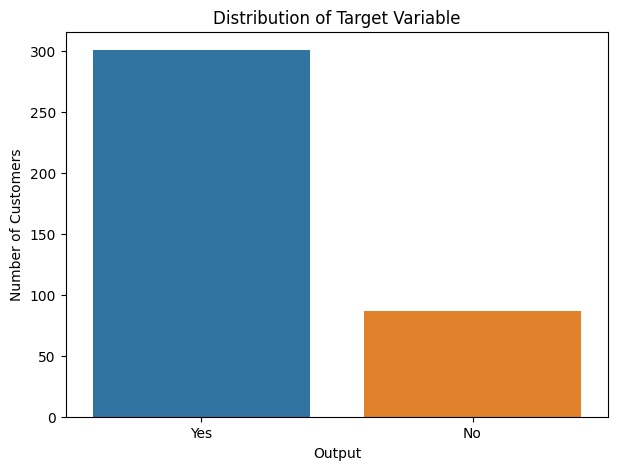

In [11]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x="Output")

plt.title("Distribution of Target Variable")
plt.xlabel("Output")
plt.ylabel("Number of Customers")
plt.show()

### 8.2 Age Distribution

Age is an important numerical feature in the dataset.

The following graph shows the distribution of customers across different age groups.

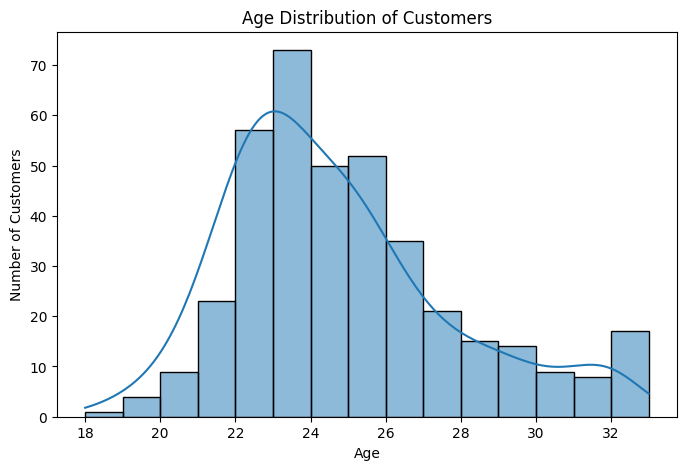

In [12]:
plt.figure(figsize=(8, 5))

sns.histplot(data=df, x="Age", bins=15, kde=True)

plt.title("Age Distribution of Customers")
plt.xlabel("Age")
plt.ylabel("Number of Customers")
plt.show()

### 8.3 Target Variable by Gender

This visualization compares the target variable across different gender categories.

It helps us observe whether the target classes are distributed differently across gender groups.

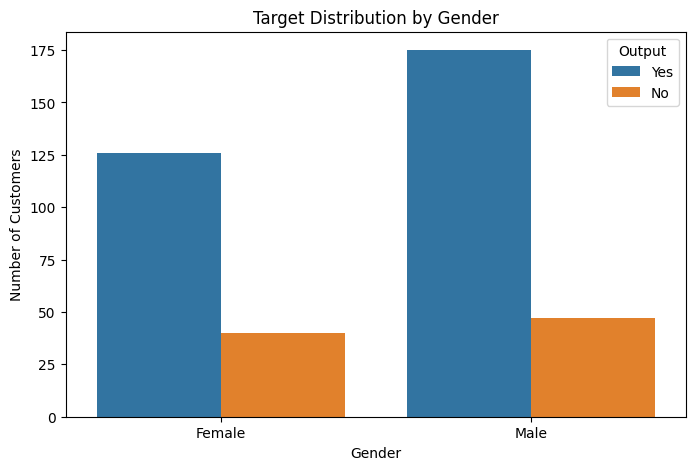

In [13]:
plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="Gender", hue="Output")

plt.title("Target Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Customers")
plt.show()

## 9. Data Preprocessing

Data preprocessing converts the raw dataset into a suitable format for the Deep Learning model.

In this step, we will:

- Separate the features and target variable.
- Convert categorical values into numerical values.
- Prepare the data for training.

### 9.1 Selecting Features and Target

The `Output` column is selected as the target variable because it represents the outcome that the model will predict.

All remaining relevant columns are used as input features.

In [14]:
X = df.drop("Output", axis=1)
y = df["Output"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (388, 13)
Target shape: (388,)


### 9.2 Checking Feature Data Types

The dataset contains both numerical and categorical features.

We need to identify these data types before converting the categorical features into numerical form.

In [15]:
X.dtypes

Age                             int64
Gender                         object
Marital Status                 object
Occupation                     object
Monthly Income                 object
Educational Qualifications     object
Family size                     int64
Customer Type                  object
latitude                      float64
longitude                     float64
Pin code                        int64
Feedback                       object
Unnamed: 13                    object
dtype: object

### 9.3 Encoding the Target Variable

The target variable must be represented numerically for model training.

`LabelEncoder` converts categorical target values into numerical labels.

In [16]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

y = label_encoder.fit_transform(y)

print("Encoded target classes:", label_encoder.classes_)

Encoded target classes: ['No' 'Yes']


### 9.4 Encoding Categorical Features

The dataset contains categorical features such as gender, occupation, marital status, and customer type.

An ANN model requires numerical input, so these categorical values must be converted into numerical form.

We use **One-Hot Encoding** to represent categorical features numerically.

In [19]:
X = pd.get_dummies(X, drop_first=True)

X.head()

,Age,Family size,latitude,longitude,Pin code,Gender_Male,Marital Status_Prefer not to say,Marital Status_Single,Occupation_House wife,Occupation_Self Employeed,...,Monthly Income_More than 50000,Monthly Income_No Income,Educational Qualifications_Ph.D,Educational Qualifications_Post Graduate,Educational Qualifications_School,Educational Qualifications_Uneducated,Customer Type_New,Customer Type_Regular,Feedback_Positive,Unnamed: 13_Yes
0,20,4,12.9766,77.5993,560001,0,0,1,0,0,...,0,1,0,1,0,0,0,0,1,1
1,24,3,12.9770,77.5773,560009,0,0,1,0,0,...,0,0,0,0,0,0,0,1,1,1
2,22,3,12.9551,77.6593,560017,1,0,1,0,0,...,0,0,0,1,0,0,0,1,0,1
3,22,6,12.9473,77.5616,560019,0,0,1,0,0,...,0,1,0,0,0,0,0,0,1,1
4,22,4,12.9850,77.5533,560010,1,0,1,0,0,...,0,0,0,1,0,0,0,0,1,1


### 9.5 Checking the Processed Features

After encoding, all categorical features are converted into numerical columns.

We now check the shape and data types of the processed feature matrix.

In [17]:
print("Processed Features Shape:", X.shape)

print("\nFeature Data Types:")
print(X.dtypes)

Processed Features Shape: (388, 13)

Feature Data Types:
Age                             int64
Gender                         object
Marital Status                 object
Occupation                     object
Monthly Income                 object
Educational Qualifications     object
Family size                     int64
Customer Type                  object
latitude                      float64
longitude                     float64
Pin code                        int64
Feedback                       object
Unnamed: 13                    object
dtype: object


In [20]:
X = X.astype(float)

X.head()

,Age,Family size,latitude,longitude,Pin code,Gender_Male,Marital Status_Prefer not to say,Marital Status_Single,Occupation_House wife,Occupation_Self Employeed,...,Monthly Income_More than 50000,Monthly Income_No Income,Educational Qualifications_Ph.D,Educational Qualifications_Post Graduate,Educational Qualifications_School,Educational Qualifications_Uneducated,Customer Type_New,Customer Type_Regular,Feedback_Positive,Unnamed: 13_Yes
0,20.0,4.0,12.9766,77.5993,560001.0,0.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0
1,24.0,3.0,12.9770,77.5773,560009.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1.0
2,22.0,3.0,12.9551,77.6593,560017.0,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0
3,22.0,6.0,12.9473,77.5616,560019.0,0.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0
4,22.0,4.0,12.9850,77.5533,560010.0,1.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,1.0


## 10. Train-Test Split

The prepared dataset is divided into two parts:

- **Training Data:** Used to train the ANN model.
- **Testing Data:** Used to evaluate the model on unseen data.

We use an **80:20 split**, where 80% of the data is used for training and 20% for testing.

In [21]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training features: (310, 23)
Testing features: (78, 23)
Training target: (310,)
Testing target: (78,)


## 11. Feature Scaling

Feature scaling brings numerical features to a similar range.

This is important for an Artificial Neural Network because features with very different scales can affect the training process.

We use **StandardScaler** to standardize the features.

In [22]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

### 11.1 Verifying Feature Scaling

After scaling, we check the transformed training data to confirm that the features have been standardized.

In [23]:
print("Scaled Training Data Shape:", X_train.shape)
print("Scaled Testing Data Shape:", X_test.shape)

print("\nFirst 5 Training Records:")
print(X_train[:5])

Scaled Training Data Shape: (310, 23)
Scaled Testing Data Shape: (78, 23)

First 5 Training Records:
[[-0.86265727 -0.95716977 -0.97411373  1.62456128  2.00289055  0.88408664
  -0.18257419  0.66472586 -0.15199444 -0.39040538 -1.07367489 -0.44374677
  -0.26261287 -0.43852901 -0.98717896 -0.25552318 -0.88989186 -0.16275769
  -0.0805823  -0.26261287  0.90159054  0.46442036  0.54006172]
 [ 1.78510267  2.04002849  0.54587686  3.05093255  0.8489278   0.88408664
  -0.18257419 -1.50437957 -0.15199444  2.56144014 -1.07367489 -0.44374677
  -0.26261287  2.28035085 -0.98717896 -0.25552318 -0.88989186 -0.16275769
  -0.0805823  -0.26261287 -1.10915095  0.46442036  0.54006172]
 [-1.19362726 -0.2078702   2.07952007 -0.15743117  1.65029082  0.88408664
  -0.18257419  0.66472586 -0.15199444 -0.39040538  0.93138063 -0.44374677
  -0.26261287 -0.43852901  1.01298756 -0.25552318 -0.88989186 -0.16275769
  -0.0805823  -0.26261287  0.90159054 -2.15322169  0.54006172]
 [-1.52459725 -0.95716977  2.29113552 -1.064

## 12. Building the Artificial Neural Network

An Artificial Neural Network (ANN) is a Deep Learning model inspired by the structure of the human brain.

The ANN consists of connected layers of neurons that learn patterns from the input data.

In this project, the ANN contains:

- **Input Layer** – Receives the processed features.
- **Hidden Layers** – Learn patterns and relationships in the data.
- **Output Layer** – Produces the final classification prediction.

In [24]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential([
    Dense(64, activation="relu", input_shape=(X_train.shape[1],)),
    Dense(32, activation="relu"),
    Dense(1, activation="sigmoid")
])

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 64)                1536      
                                                                 
 dense_1 (Dense)             (None, 32)                2080      
                                                                 
 dense_2 (Dense)             (None, 1)                 33        
                                                                 
Total params: 3,649
Trainable params: 3,649
Non-trainable params: 0
_________________________________________________________________


## 13. Compiling the ANN Model

Before training the Artificial Neural Network, the model must be compiled.

The following components are defined:

- **Optimizer:** Adam – updates the model weights during training.
- **Loss Function:** Binary Crossentropy – suitable for binary classification.
- **Metric:** Accuracy – measures the percentage of correct predictions.

In [26]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

## 14. Training the ANN Model

The ANN model is trained using the training dataset.

During training, the model learns patterns from the input features and adjusts its weights to improve prediction accuracy.

The training process is performed over multiple **epochs**.

In [27]:
history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=32,
    verbose=1
)

Epoch 1/50
8/8 [==============================] - 2s 62ms/step - loss: 0.6518 - accuracy: 0.6371 - val_loss: 0.5727 - val_accuracy: 0.7903
Epoch 2/50
8/8 [==============================] - 0s 9ms/step - loss: 0.5266 - accuracy: 0.8347 - val_loss: 0.4553 - val_accuracy: 0.9194
Epoch 3/50
8/8 [==============================] - 0s 9ms/step - loss: 0.4346 - accuracy: 0.8669 - val_loss: 0.3657 - val_accuracy: 0.9516
Epoch 4/50
8/8 [==============================] - 0s 8ms/step - loss: 0.3582 - accuracy: 0.8992 - val_loss: 0.2937 - val_accuracy: 0.9677
Epoch 5/50
8/8 [==============================] - 0s 9ms/step - loss: 0.2940 - accuracy: 0.9234 - val_loss: 0.2378 - val_accuracy: 0.9677
Epoch 6/50
8/8 [==============================] - 0s 9ms/step - loss: 0.2384 - accuracy: 0.9476 - val_loss: 0.1933 - val_accuracy: 0.9677
Epoch 7/50
8/8 [==============================] - 0s 10ms/step - loss: 0.1923 - accuracy: 0.9556 - val_loss: 0.1570 - val_accuracy: 0.9677
Epoch 8/50
8/8 [================

## 15. Training Performance

The training history contains the model's accuracy and loss values for each epoch.

Visualizing these values helps us understand how the model learns during training.

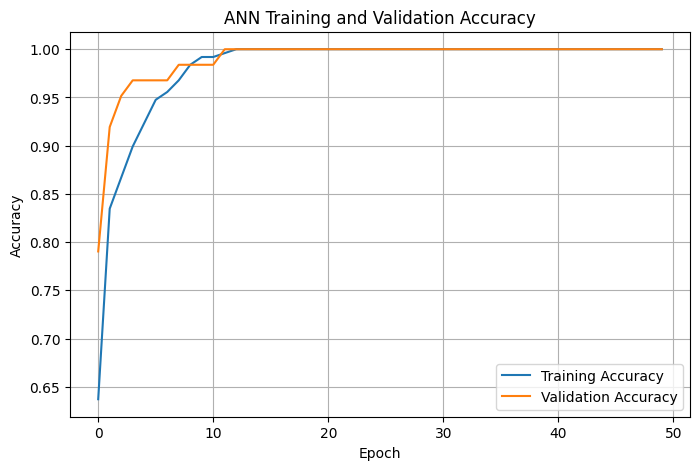

In [28]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("ANN Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()

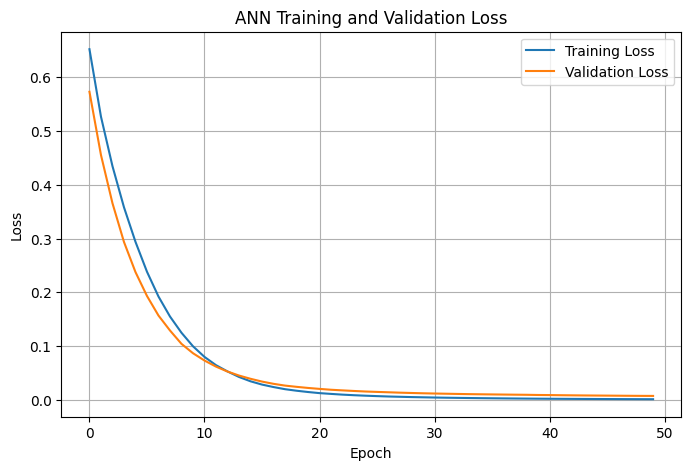

In [29]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("ANN Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

## 16. Model Evaluation

After training the ANN model, we evaluate its performance using the unseen testing dataset.

The main evaluation metric for this binary classification problem is **Accuracy**.

Accuracy represents the proportion of correctly predicted observations out of all observations.

In [30]:
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

Test Loss: 0.006720655132085085
Test Accuracy: 1.0


### 16.1 Making Predictions

The trained ANN model produces probability values between 0 and 1.

A threshold of 0.5 is used to convert these probabilities into binary class predictions.

In [31]:
y_prob = model.predict(X_test)

y_pred = (y_prob >= 0.5).astype(int).ravel()

print("First 10 Predicted Values:")
print(y_pred[:10])

3/3 [==============================] - 0s 5ms/step
First 10 Predicted Values:
[1 1 1 1 1 1 1 1 1 1]


### 16.2 Classification Report

The Classification Report provides detailed information about the performance of the ANN model.

It includes:

- **Precision** – Measures how many predicted positive cases are actually positive.
- **Recall** – Measures how many actual positive cases were correctly identified.
- **F1-score** – Represents the balance between Precision and Recall.
- **Support** – Shows the number of actual samples in each class.

In [32]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        17
           1       1.00      1.00      1.00        61

    accuracy                           1.00        78
   macro avg       1.00      1.00      1.00        78
weighted avg       1.00      1.00      1.00        78



### 16.3 Confusion Matrix

A Confusion Matrix compares the actual classes with the classes predicted by the ANN model.

It helps us identify:

- True Positives
- True Negatives
- False Positives
- False Negatives

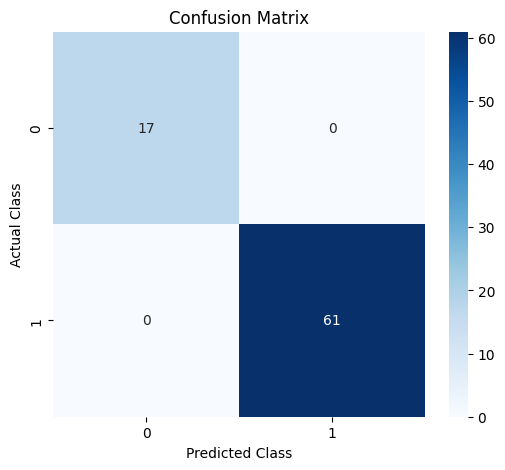

In [33]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")
plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.show()

## 17. Final Model Accuracy

The final accuracy of the trained ANN model is calculated using the predictions made on the testing dataset.

This represents how accurately the model classifies unseen data.

In [34]:
final_accuracy = accuracy_score(y_test, y_pred)

print("Final Test Accuracy:", final_accuracy)

Final Test Accuracy: 1.0


## 18. Key Observations

The following observations were obtained from the Online Food Delivery dataset and the ANN model:

- The dataset contains customer-related information about online food ordering.
- Data preprocessing was performed before model training.
- Categorical features were converted into numerical form using One-Hot Encoding.
- The target variable was encoded using Label Encoding.
- The dataset was divided into training and testing sets using an 80:20 split.
- Feature scaling was applied to improve the ANN training process.
- An Artificial Neural Network was built using TensorFlow.
- The model was trained using the Adam optimizer and Binary Crossentropy loss.
- Model performance was evaluated using accuracy, precision, recall, and F1-score.
- A confusion matrix was used to analyze the classification results.

## 19. Conclusion

This project demonstrates the use of Deep Learning for classification using an Online Food Delivery dataset.

The dataset was explored, cleaned, transformed, and prepared for model training. An Artificial Neural Network was developed using TensorFlow and trained to classify the target variable.

The model was evaluated using test accuracy, classification metrics, and a confusion matrix.

This project demonstrates a complete Deep Learning workflow from data preprocessing to model evaluation.

# 20. Quick Revision

**Dataset:** Online Food Delivery Dataset

**Machine Learning Type:** Supervised Learning – Classification

**Deep Learning Technique:** Artificial Neural Network (ANN)

**Framework:** TensorFlow

**Target Variable:** `Output`

**Encoding:** One-Hot Encoding + Label Encoding

**Data Split:** 80% Training / 20% Testing

**Feature Scaling:** StandardScaler

**Optimizer:** Adam

**Loss Function:** Binary Crossentropy

**Evaluation Metrics:**
- Accuracy
- Precision
- Recall
- F1-score
- Confusion Matrix

### Deep Learning Workflow

**Data → Exploration → Cleaning → EDA → Feature Preparation → Encoding → Train/Test Split → Scaling → ANN → Training → Prediction → Evaluation → Conclusion**